# Accessing EIC Data with Rucio

In this notebook we will learn how to find and access ePIC simulation data using **Rucio**, the data management system used by the EIC.

## What is Rucio?

Rucio is a tool that keeps track of where all the EIC data files are stored across different computing sites around the world (like JLab and BNL). Instead of needing to know exactly where a file lives, you can ask Rucio to find it for you.

Once Rucio tells you where a file is, we use **XRootD** to actually stream or download it — think of Rucio as the catalog and XRootD as the delivery truck.

## What will we do in this notebook?

1. Check we can connect to Rucio
2. Learn about Data Identifiers (DIDs) — how EIC files are named
3. Use metadata tags to find DIS data files
4. Stream a file directly and check its contents
5. Do a simple analysis with uproot

## 1. Check Rucio is Working

First, let's make sure we can connect to Rucio and check who we are logged in as.

In [1]:
# Check Rucio is available and we can connect
!rucio whoami

status     : ACTIVE
email      : eicprod@jlab.org
account_type : GROUP
deleted_at : None
updated_at : 2024-12-18T17:22:11
account    : eicread
suspended_at : None
created_at : 2024-12-18T14:40:56
>

You should see output showing you are connected as the `eicread` account. This is a shared read-only account that gives everyone access to public ePIC data.

If you see an error, make sure you are running this notebook inside the eic-shell environment.

## 2. Understanding Data Identifiers (DIDs)

Every file or dataset in Rucio has a unique name called a **Data Identifier (DID)**. For ePIC data, DIDs always look like:

```
epic:name
```

where `epic` is the **scope** (it's always `epic` for our data) and `name` describes what the data is.

For example, a DIS dataset might look like:

```
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10
```

Breaking this down:
- `RECO` — reconstructed data (not raw simulation)
- `26.02.0` — software release used (February 2026)
- `epic_craterlake` — detector configuration
- `DIS/NC` — Deep Inelastic Scattering, Neutral Current
- `18x275` — 18 GeV electrons on 275 GeV protons
- `minQ2=10` — minimum Q² of 10 GeV²

> **Note:** Even though the name looks like a file path, it is **not** a directory structure — it is just a flat name.

## 3. Finding DIS Data Using Metadata Tags

Rather than guessing DID names, we can search using **metadata tags**. These are labels attached to datasets that describe the physics content.

Useful tags for DIS data:
- `electron_beam_energy_gev` — electron beam energy
- `ion_beam_energy_gev` — ion beam energy  
- `q2_min_gev2` — minimum Q²
- `data_level` — `reconstruction` or `simulation`
- `software_release` — which software version was used

Let's find DIS datasets with 18 GeV electrons on 275 GeV protons:

In [2]:
# Find DIS datasets with 18x275 beam energies
!rucio did list --filter 'electron_beam_energy_gev==18, ion_beam_energy_gev==275' 'epic:*'

+----------------------------------------------------------------------------------------------------------------------------------+--------------+
| SCOPE:NAME                                                                                                                       | [DID TYPE]   |
|----------------------------------------------------------------------------------------------------------------------------------+--------------|
| epic:/RECO/26.04.1/epic_craterlake/DIS/NC/18x275/minQ2=1                                                                         | N/A          |
| epic:/FULL/main/epic_craterlake/Test/2026-04-06_21-14-00/DIS/NC/18x275/minQ2=1                                                   | N/A          |
| epic:/RECO/main/epic_craterlake/Test/2026-04-06_21-14-00/DIS/NC/18x275/minQ2=1                                                   | N/A          |
| epic:/FULL/main/epic_craterlake/Test/2026-04-06_21-31-00/DIS/NC/18x275/minQ2=1                                

In [15]:
# We can narrow it down further by adding more filters
# Let's find only reconstructed data from 2026 software releases
!rucio did list --filter 'electron_beam_energy_gev==18, ion_beam_energy_gev==275, data_level==reconstruction' 'epic:*'

+----------------------------------------------------------------------------------------------------------------------+--------------+
| SCOPE:NAME                                                                                                           | [DID TYPE]   |
|----------------------------------------------------------------------------------------------------------------------+--------------|
| epic:/RECO/26.04.1/epic_craterlake/DIS/NC/10x100/minQ2=10                                                            | N/A          |
| epic:/RECO/26.03.0/epic_craterlake/DIS/CC/10x100/minQ2=100                                                           | N/A          |
| epic:/RECO/26.03.0/epic_craterlake/DIS/CC/10x100/minQ2=1000                                                          | N/A          |
| epic:/RECO/26.04.1/epic_craterlake/EXCLUSIVE/DIFFRACTIVE_JPSI_ABCONV/lAger3.6.1-1.0/10x100/hiAcc                     | N/A          |
| epic:/RECO/26.03.0/epic_craterlake/DIS/NC/10x1

## 4. Exploring a Dataset

Once we have a DID, we can look inside it to see what files it contains.

Let's pick a DIS dataset and explore it. Replace the DID below with one from your search results above:

In [3]:
# Set our DID - update this with a result from your search above
did = "epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10"

# List the files in this dataset (--short gives us just the names)
!rucio did content list --short {did}

epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0000.eicrecon.edm4eic.root
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0001.eicrecon.edm4eic.root
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0002.eicrecon.edm4eic.root
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0003.eicrecon.edm4eic.root
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0004.eicrecon.edm4eic.root
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0005.eicrecon.edm4eic.root
epic:/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025

In [ ]:
# Find where a file in this dataset is physically stored
!rucio replica list file --protocols root --pfns --rses isopenaccess {did}

You should see a URL starting with `root://dtn-eic.jlab.org` — this tells us the file is stored at JLab and gives us the full path we need to stream it.

## 5. Streaming a File with XRootD and Uproot

Now we know where our file is, we can stream it directly — no need to download the whole thing first!

We'll use the file path from the `rucio replica list` output above. Update `file_path` below with your path:

In [4]:
import uproot
import XRootD

# Update this with the path from your rucio replica list output above
file_path = "root://dtn-eic.jlab.org:1094//volatile/eic/EPIC/RECO/26.02.0/epic_craterlake/DIS/NC/18x275/minQ2=10/pythia8NCDIS_18x275_minQ2=10_beamEffects_xAngle=-0.025_hiDiv_1.0000.eicrecon.edm4eic.root"

# Open the file - this streams it, no download needed!
root_file = uproot.open(file_path)
print("File opened successfully!")
print("Contents:", root_file.keys())

File opened successfully!
Contents: ['events;4', 'events;3', 'podio_metadata;1']


In [5]:
# Open the events tree and check how many events we have
events = root_file['events']
print(f"Number of events: {events.num_entries}")

# See what branches (data columns) are available
print("\nAvailable branches (first 20):")
for branch in list(events.keys())[:20]:
    print(" -", branch)

Number of events: 410

Available branches (first 20):
 - B0ECalClusterAssociations
 - B0ECalClusterAssociations/B0ECalClusterAssociations.weight
 - _B0ECalClusterAssociations_rec
 - _B0ECalClusterAssociations_rec/_B0ECalClusterAssociations_rec.index
 - _B0ECalClusterAssociations_rec/_B0ECalClusterAssociations_rec.collectionID
 - _B0ECalClusterAssociations_sim
 - _B0ECalClusterAssociations_sim/_B0ECalClusterAssociations_sim.index
 - _B0ECalClusterAssociations_sim/_B0ECalClusterAssociations_sim.collectionID
 - B0ECalClusters
 - B0ECalClusters/B0ECalClusters.type
 - B0ECalClusters/B0ECalClusters.energy
 - B0ECalClusters/B0ECalClusters.energyError
 - B0ECalClusters/B0ECalClusters.time
 - B0ECalClusters/B0ECalClusters.timeError
 - B0ECalClusters/B0ECalClusters.nhits
 - B0ECalClusters/B0ECalClusters.position.x
 - B0ECalClusters/B0ECalClusters.position.y
 - B0ECalClusters/B0ECalClusters.position.z
 - B0ECalClusters/B0ECalClusters.positionError.xx
 - B0ECalClusters/B0ECalClusters.positionError

## 6. Simple Analysis — Looking at Reconstructed Tracks

Now let's do something simple with the data — look at the reconstructed particle tracks.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Read a small batch of events (first 1000) to keep things fast
# ReconstructedChargedParticles contains the reconstructed tracks
data = events.arrays(
    ["ReconstructedChargedParticles.momentum.x",
     "ReconstructedChargedParticles.momentum.y",
     "ReconstructedChargedParticles.momentum.z",
     "ReconstructedChargedParticles.energy"],
    entry_stop=1000
)

print("Data loaded successfully!")

Data loaded successfully!


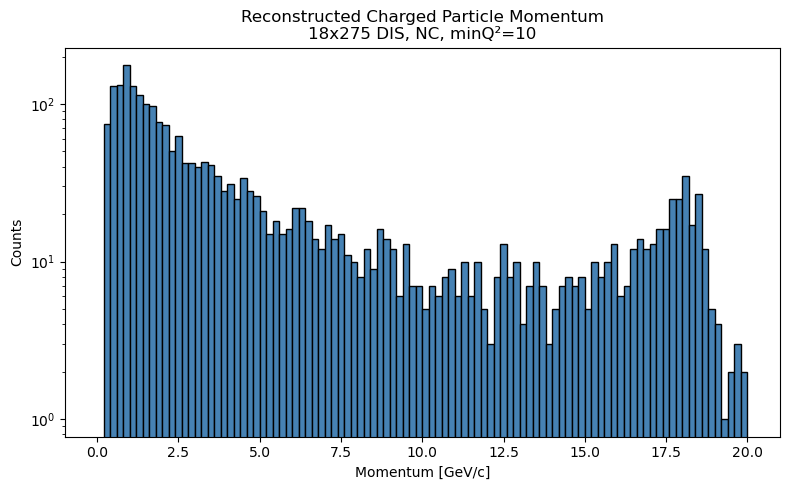

In [7]:
# Calculate momentum magnitude for all particles in all events
px = np.concatenate(data["ReconstructedChargedParticles.momentum.x"].to_list())
py = np.concatenate(data["ReconstructedChargedParticles.momentum.y"].to_list())
pz = np.concatenate(data["ReconstructedChargedParticles.momentum.z"].to_list())

p = np.sqrt(px**2 + py**2 + pz**2)

# Plot the momentum distribution
plt.figure(figsize=(8, 5))
plt.hist(p, bins=100, range=(0, 20), color='steelblue', edgecolor='black')
plt.xlabel('Momentum [GeV/c]')
plt.ylabel('Counts')
plt.title('Reconstructed Charged Particle Momentum\n18x275 DIS, NC, minQ²=10')
plt.yscale('log')
plt.tight_layout()
plt.show()

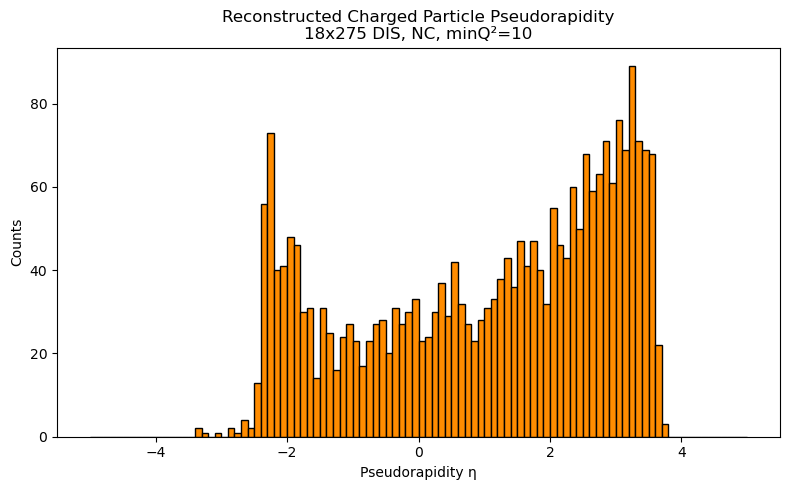

In [8]:
# Calculate pseudorapidity (eta) — useful for understanding detector coverage
pt = np.sqrt(px**2 + py**2)
theta = np.arctan2(pt, pz)
eta = -np.log(np.tan(theta / 2))

# Remove any infinite values
eta = eta[np.isfinite(eta)]

plt.figure(figsize=(8, 5))
plt.hist(eta, bins=100, range=(-5, 5), color='darkorange', edgecolor='black')
plt.xlabel('Pseudorapidity η')
plt.ylabel('Counts')
plt.title('Reconstructed Charged Particle Pseudorapidity\n18x275 DIS, NC, minQ²=10')
plt.tight_layout()
plt.show()

## Summary

In this notebook we have:

- ✅ Connected to Rucio and checked our account
- ✅ Learned about DIDs and how EIC data is named
- ✅ Used metadata tags to search for DIS datasets
- ✅ Found where files are physically stored
- ✅ Streamed a file using XRootD without downloading it
- ✅ Done a simple analysis of reconstructed tracks

## Exercise

Try finding and streaming a DIS dataset with different beam energies, for example 10x100. What differences do you see in the momentum and pseudorapidity distributions?

**Hint:** Use `rucio did list --filter 'electron_beam_energy_gev==10, ion_beam_energy_gev==100, data_level==reconstruction' 'epic:*'` to find it.